# Kalibracja wzmacniacza oraz generatora sygnałów

W tym pliku przedstawiono proces kalibracji wzmacniacza w celu wybrania odpowiedniej wartości czasu kształtowania oraz kalibrację generatora sygnałów, tak aby potencjometr wskazywał wartość energii (MeV), która generowałaby jego sygnał. 

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use('seaborn-v0_8-whitegrid')

### Funkcja pobierająca dane z pliku .lst

In [81]:
def load_lst(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Znajdź linię, po której zaczynają się dane (pod $DATA:)
    start_idx = 0
    for i, line in enumerate(lines):
        if '$DATA:' in line:
            start_idx = i + 2  # Dane zaczynają się dwie linie niżej
            break
            
    # Wczytaj dane (kanał i liczba zliczeń)
    # Dane są rozdzielone spacjami
    data = pd.read_csv(filename, skiprows=start_idx, sep=r'\s+', 
                       header=None, names=['channel', 'counts'], nrows=8192)
    return data

### Obliczenie parametrów dopasowania Gaussa

In [82]:
def gaussian(x, A, mu, sigma):
    # Człon normalizujący sprawia, że A to pole pod krzywą
    normalization = A / (np.sqrt(2 * np.pi * sigma**2))
    exponent = np.exp(-(x - mu)**2 / (2 * sigma**2))
    return normalization * exponent


def gaussian_fit_parameters(df, xmin, xmax):
    peak_range = df[(df['channel'] > xmin) & (df['channel'] < xmax)]
    x = peak_range['channel']
    y = peak_range['counts']
    

    sigma_init = 10
    a_init = max(y) * sigma_init * np.sqrt(2*np.pi)
    initial_guess = [a_init, x.iloc[np.argmax(y.values)], sigma_init]
    
    # Dopasowanie krzywej
    popt, _ = curve_fit(gaussian, x, y, p0=initial_guess)
    a, mu, sigma = popt
    fwhm = 2.355 * abs(sigma)
    
    return a, mu, sigma, fwhm

In [83]:
files_amp = {
    '0,5s': 'dane/01kalibracja_urzadzen/wzmacniacz0_5s.lst',
    '1,0s': 'dane/01kalibracja_urzadzen/wzmacniacz1_0s.lst',
    '2,0s': 'dane/01kalibracja_urzadzen/wzmacniacz2_0s.lst'
}

results = {}

for label, path in files_amp.items():
    df = load_lst(path)
    
    a, mu, sigma, fwhm = gaussian_fit_parameters(df, 1000, 1200)
    
    results[label] = {'mu': mu, 'fwhm': fwhm, 'data': df}
    print(f"Czas {label}: FWHM = {fwhm:.2f} kanałów")

Czas 0,5s: FWHM = 16.46 kanałów
Czas 1,0s: FWHM = 16.29 kanałów
Czas 2,0s: FWHM = 19.77 kanałów


### Wykres obrazujący rozkłady dla różnych ustawień wzmacniacza

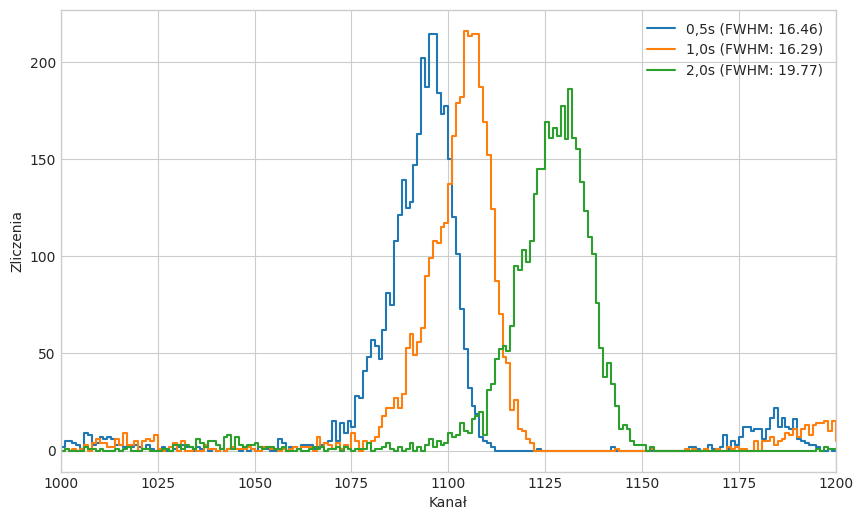

In [84]:
plt.figure(figsize=(10, 6))
for label, res in results.items():
    df = res['data']
    plt.step(df['channel'], df['counts'], label=f"{label} (FWHM: {res['fwhm']:.2f})")

plt.xlim(1000, 1200) # Skupienie na obszarze piku
plt.xlabel("Kanał")
plt.ylabel("Zliczenia")
plt.legend()
plt.show()
# Wnioski: Najlepsza wartość to ta z najmniejszym FWHM.

### Ustawienie generatora impulsów
W badanej próbce uranu zawierającej: 234U (1%), 235U (10 %), 238U (89%), obliczono aktywność rozpadów alpha wszystkich trzech izotopów. Najbardziej aktywny okazał się izotop 234U, dla którego energia rozpadu alpha wynosi około 4,76 MeV. W celu kalibracji generatora impulsów ustawiono potencjometr na wartość 4,76 i przekręcano pokrętło kalibracyjne tak aby rozkład impulsów z generatora z rozkładem impulsów wynikających z rozpadów alpha 234U nakładały się tworząc w przybliżeniu jeden rozkład Gaussa. Po kalibracji przyjęto że wartość wskazana przez potencjometr generatora impulsów odpowiada energii produktu rozpadu w MeV.

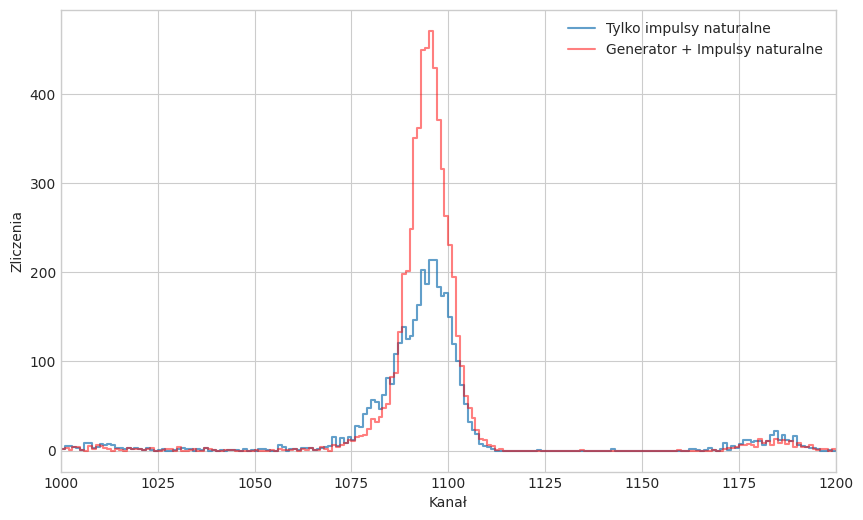

In [85]:
df_gen = load_lst('dane/01kalibracja_urzadzen/generator_impulsow.lst')
df_natural = load_lst('dane/01kalibracja_urzadzen/wzmacniacz0_5s.lst') # Przykładowy plik bez generatora

plt.figure(figsize=(10, 6))
plt.step(df_natural['channel'], df_natural['counts'], label='Tylko impulsy naturalne', alpha=0.7)
plt.step(df_gen['channel'], df_gen['counts'], label='Generator + Impulsy naturalne', color='red', alpha=0.5)

plt.xlim(1000, 1200) # Zakres piku alfa
plt.xlabel("Kanał")
plt.ylabel("Zliczenia")
plt.legend()
plt.show()

Impulsy naturalne: mu=1094.97 
Generator + impulsy naturalne: mu=1095.49


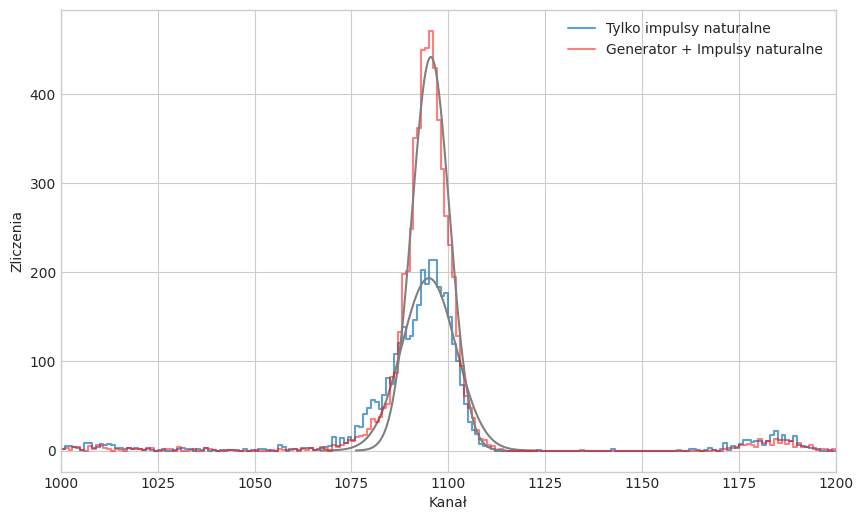

In [86]:
a_gen, mu_gen, sigma_gen, fwhm_gen = gaussian_fit_parameters(df_gen, 1050, 1125)
a_nat, mu_nat,sigma_nat, fwhm_nat = gaussian_fit_parameters(df_natural, 1050, 1125)

print(f"Impulsy naturalne: mu={mu_nat:.2f} \nGenerator + impulsy naturalne: mu={mu_gen:.2f}")

plt.figure(figsize=(10, 6))
plt.step(df_natural['channel'], df_natural['counts'], label='Tylko impulsy naturalne', alpha=0.7)

x_nat_values = np.linspace(mu_nat - 4*sigma_nat, mu_nat + 4*sigma_nat, 500)
y_nat_values = gaussian(x_nat_values, a_nat, mu_nat, sigma_nat)

plt.plot(x_nat_values, y_nat_values, color='grey')

plt.step(df_gen['channel'], df_gen['counts'], label='Generator + Impulsy naturalne', color='red', alpha=0.5)

x_gen_values = np.linspace(mu_gen - 4*sigma_gen, mu_gen + 4*sigma_gen, 500)
y_gen_values = gaussian(x_gen_values, a_gen, mu_gen, sigma_gen)

plt.plot(x_gen_values, y_gen_values, color='grey')

plt.xlim(1000, 1200) # Zakres piku alfa
plt.xlabel("Kanał")
plt.ylabel("Zliczenia")
plt.legend()
plt.show()